# Notebook 08-UNSW — SCTS-v2 Trust Score on UNSW-NB15

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection
**Author:** Md Anas Biswas, University of Portsmouth
**Contribution covered:** C4 — SCTS-v2 trust score (extended from NSL-KDD to UNSW-NB15)

## What this notebook does

Extends the SCTS-v2 trust score (originally computed only on NSL-KDD in Notebook 07) to UNSW-NB15. The methodology is replicated exactly from Notebook 07 to preserve cross-dataset consistency. SCTS-v2 combines three trust components into a single 0-100 score:

- **c1: Calibrated confidence** — predicted-class probability from per-class isotonic calibrator
- **c2: Per-sample worst-case Jaccard@10** — minimum Jaccard top-10 across Gaussian, FGSM, PGD perturbations
- **c3: Conformal coverage signal** — proximity to conformal threshold at α=0.05

SCTS-v2 = (c1 × c2 × c3)^(1/3) × 100

## Sample-size note

Per Notebook 05-UNSW, UNSW-NB15 has *two distinct stability subsamples* due to UNSW's deep RF trees making TreeExplainer slow:
- **Tree models (RF, XGB):** 215 stratified samples with min-per-class floor of 15
- **DNN models:** 509 stratified samples with min-per-class floor of 15

We compute SCTS-v2 within each architecture group on its own stability subsample. This is honest and documented in the methodology — UNSW-NB15 is the only dataset where this asymmetry exists, and it is a consequence of the depth-46 RF training (planned pre-submission fix: retrain UNSW RF with max_depth=20).

## Outputs (mirroring NSL-KDD naming convention)

- `results/tables/unsw_scts_validation.csv` — quartile stratification
- `results/tables/unsw_scts_summary.csv` — per-class SCTS means
- `results/tables/unsw_scts_alpha_sensitivity.csv` — α sensitivity
- `results/figures/unsw_scts_distributions.png` — SCTS distributions per model
- `results/figures/unsw_scts_reliability.png` — empirical accuracy vs SCTS
- `results/scts/unsw_scts_per_sample.npz` — per-sample SCTS arrays
- `results/scts/unsw_components_per_sample.npz` — c1/c2/c3 per sample
- `results/scts/unsw_conformal_thresholds.json` — conformal thresholds and empirical coverage

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
REPO = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(REPO)

for f in ['.gitconfig', '.git-credentials']:
    src = f'/content/drive/MyDrive/XIDS_Research/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/root/{f}')
        if f == '.git-credentials':
            os.chmod(f'/root/{f}', 0o600)

!git pull
print(f'\n✓ Ready in: {os.getcwd()}')

Mounted at /content/drive
Already up to date.

✓ Ready in: /content/drive/MyDrive/XIDS_Research/xids-research


In [2]:
import numpy as np
import pandas as pd
import json
from pathlib import Path

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Paths — UNSW-NB15 specific
PROCESSED  = Path(REPO) / 'data' / 'processed' / 'unsw_nb15'
MODELS_DIR = Path(REPO) / 'models' / 'unsw_nb15'
CALIB_DIR  = Path(REPO) / 'calibrators' / 'unsw_nb15'
CALIB_PROBS_DIR = CALIB_DIR / 'calibrated_probas'
SHAP_DIR   = Path(REPO) / 'shap_values' / 'unsw_nb15'
STAB_DIR   = SHAP_DIR / 'stability'
SCTS_DIR   = Path(REPO) / 'results' / 'scts'
FIG_DIR    = Path(REPO) / 'results' / 'figures'
TABLES_DIR = Path(REPO) / 'results' / 'tables'
for d in [SCTS_DIR, FIG_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Paths configured.')

Paths configured.


In [4]:
print(f'len(idx_eval):  {len(idx_eval)}')
print(f'len(idx_calib): {len(idx_calib)}')
print(f'len(X_test):    {len(X_test)}')
print(f'len(shap_idx):  {len(shap_idx)}')
print(f'shap_idx range: min={shap_idx.min()}, max={shap_idx.max()}')
print(f'tree_local range: min={tree_local.min()}, max={tree_local.max()}')

# Critical: is shap_idx indexing into eval half or full test?
print(f'\nIs shap_idx within idx_eval range? {shap_idx.max() < len(idx_eval)}')
print(f'Is shap_idx within X_test range?   {shap_idx.max() < len(X_test)}')

# Check overlap of shap_idx with idx_eval (assuming shap_idx is into X_test)
if shap_idx.max() < len(X_test):
    overlap_with_eval = np.isin(shap_idx, idx_eval).sum()
    overlap_with_calib = np.isin(shap_idx, idx_calib).sum()
    print(f'\nshap_idx samples in idx_eval:  {overlap_with_eval} / {len(shap_idx)}')
    print(f'shap_idx samples in idx_calib: {overlap_with_calib} / {len(shap_idx)}')

len(idx_eval):  31731
len(idx_calib): 31730
len(X_test):    63461
len(shap_idx):  2000
shap_idx range: min=112, max=63457
tree_local range: min=19, max=1997

Is shap_idx within idx_eval range? False
Is shap_idx within X_test range?   True

shap_idx samples in idx_eval:  2000 / 2000
shap_idx samples in idx_calib: 0 / 2000


## 2. Load data and stability subsamples

In [5]:
# Load processed data and targets
X_test = np.load(PROCESSED / 'X_test.npy')
y_test_b = np.load(PROCESSED / 'y_test_binary.npy')
y_test_5 = np.load(PROCESSED / 'y_test_5class.npy')

# Calibration eval-half indices (from Notebook 03-UNSW)
idx_eval  = np.load(CALIB_DIR / 'idx_eval.npy')
idx_calib = np.load(CALIB_DIR / 'idx_calib.npy')

# SHAP subsample (from Notebook 04-UNSW) — these are DIRECT test-set indices
# All 2000 fall within idx_eval (verified: zero overlap with idx_calib)
shap_idx = np.load(SHAP_DIR / 'shap_subsample_idx.npy')

# Stability subsamples (from Notebook 05-UNSW) — local indices into the 2000-sample SHAP pool
tree_local = np.load(STAB_DIR / 'tree_subsample_local_idx.npy')
dnn_local  = np.load(STAB_DIR / 'dnn_subsample_local_idx.npy')

# Map: stability subset → test-set indices
tree_in_test = shap_idx[tree_local]
dnn_in_test  = shap_idx[dnn_local]

# Map: stability subset → positions in the eval half (for indexing calibrated probas)
# Calibrated probas are saved as (eval_n, n_classes), indexed by position within idx_eval
eval_position_lookup = {int(v): i for i, v in enumerate(idx_eval)}
tree_in_eval = np.array([eval_position_lookup[int(i)] for i in tree_in_test])
dnn_in_eval  = np.array([eval_position_lookup[int(i)] for i in dnn_in_test])

# Sanity check
assert np.array_equal(idx_eval[tree_in_eval], tree_in_test), "tree mapping inconsistent"
assert np.array_equal(idx_eval[dnn_in_eval], dnn_in_test), "dnn mapping inconsistent"

FIVE_CLASS_NAMES = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
BINARY_CLASS_NAMES = ['Normal', 'Attack']

print(f'Calib half:        {len(idx_calib):,} samples')
print(f'Eval half:         {len(idx_eval):,} samples')
print(f'SHAP subsample:    {len(shap_idx):,} samples (subset of eval, by direct test-set index)')
print(f'Tree stab subset:  {len(tree_local):,} samples (subset of SHAP)')
print(f'DNN stab subset:   {len(dnn_local):,} samples (subset of SHAP)')

print(f'\nTree subset 5-class distribution:')
for cid in range(5):
    n = (y_test_5[tree_in_test] == cid).sum()
    print(f'  {FIVE_CLASS_NAMES[cid]:8s}: {n:>3d}')

print(f'\nDNN subset 5-class distribution:')
for cid in range(5):
    n = (y_test_5[dnn_in_test] == cid).sum()
    print(f'  {FIVE_CLASS_NAMES[cid]:8s}: {n:>3d}')

Calib half:        31,730 samples
Eval half:         31,731 samples
SHAP subsample:    2,000 samples (subset of eval, by direct test-set index)
Tree stab subset:  215 samples (subset of SHAP)
DNN stab subset:   509 samples (subset of SHAP)

Tree subset 5-class distribution:
  Normal  : 116
  DoS     :  15
  Probe   :  15
  R2L     :  56
  U2R     :  13

DNN subset 5-class distribution:
  Normal  : 291
  DoS     :  32
  Probe   :  33
  R2L     : 140
  U2R     :  13


## 3. Define canonical models and verify required artifacts

In [6]:
CANONICAL = {
    'rf_binary_cw':      {'target': 'binary', 'arch': 'tree'},
    'xgb_binary_cw':     {'target': 'binary', 'arch': 'tree'},
    'dnn_binary_cw':     {'target': 'binary', 'arch': 'dnn'},
    'rf_5class_smote':   {'target': '5class', 'arch': 'tree'},
    'xgb_5class_smote':  {'target': '5class', 'arch': 'tree'},
    'dnn_5class_smote':  {'target': '5class', 'arch': 'dnn'},
}

# Helper to get the right stability subset for each model
def get_stab_indices(name):
    """Return (local_idx_into_SHAP_pool, idx_into_eval_half, idx_into_test_set)
    for the appropriate architecture's stability subsample."""
    if CANONICAL[name]['arch'] == 'dnn':
        return dnn_local, dnn_in_eval, dnn_in_test
    else:
        return tree_local, tree_in_eval, tree_in_test

# Verify all required files exist
print('Required artifacts:')
for name in CANONICAL:
    # Calibrated probabilities — load to inspect existence/shape
    cal_path1 = CALIB_PROBS_DIR / f'{name}_calibrated.npy'
    cal_path2 = CALIB_PROBS_DIR / f'{name}_calibrated_proba.npy'
    cal_exists = cal_path1.exists() or cal_path2.exists()
    cal_file = cal_path1 if cal_path1.exists() else cal_path2
    status = '✓' if cal_exists else '✗'
    if cal_exists:
        arr = np.load(cal_file)
        print(f'  {status} {cal_file.name}: shape={arr.shape}')
    else:
        print(f'  {status} calibrated probas for {name}: NOT FOUND')

    # Original SHAP — from Notebook 04
    orig_shap = SHAP_DIR / f'{name}_shap.npy'
    status = '✓' if orig_shap.exists() else '✗'
    print(f'  {status} original SHAP: {orig_shap.name}')

    # Perturbed SHAP — from Notebook 05
    for pert in ['gaussian', 'fgsm', 'pgd']:
        pp = STAB_DIR / f'{name}_{pert}_shap.npy'
        status = '✓' if pp.exists() else '✗'
        print(f'  {status} {pert} SHAP: {pp.name}')

Required artifacts:
  ✗ calibrated probas for rf_binary_cw: NOT FOUND
  ✓ original SHAP: rf_binary_cw_shap.npy
  ✓ gaussian SHAP: rf_binary_cw_gaussian_shap.npy
  ✓ fgsm SHAP: rf_binary_cw_fgsm_shap.npy
  ✓ pgd SHAP: rf_binary_cw_pgd_shap.npy
  ✗ calibrated probas for xgb_binary_cw: NOT FOUND
  ✓ original SHAP: xgb_binary_cw_shap.npy
  ✓ gaussian SHAP: xgb_binary_cw_gaussian_shap.npy
  ✓ fgsm SHAP: xgb_binary_cw_fgsm_shap.npy
  ✓ pgd SHAP: xgb_binary_cw_pgd_shap.npy
  ✗ calibrated probas for dnn_binary_cw: NOT FOUND
  ✓ original SHAP: dnn_binary_cw_shap.npy
  ✓ gaussian SHAP: dnn_binary_cw_gaussian_shap.npy
  ✓ fgsm SHAP: dnn_binary_cw_fgsm_shap.npy
  ✓ pgd SHAP: dnn_binary_cw_pgd_shap.npy
  ✗ calibrated probas for rf_5class_smote: NOT FOUND
  ✓ original SHAP: rf_5class_smote_shap.npy
  ✓ gaussian SHAP: rf_5class_smote_gaussian_shap.npy
  ✓ fgsm SHAP: rf_5class_smote_fgsm_shap.npy
  ✓ pgd SHAP: rf_5class_smote_pgd_shap.npy
  ✗ calibrated probas for xgb_5class_smote: NOT FOUND
  ✓ origi

## 4. Component 1 — Calibrated confidence

For each sample, the predicted-class probability from the calibrated probabilities, restricted to that architecture's stability subset.

In [24]:
def load_calibrated_probas(name):
    """Load calibrated probabilities for UNSW-NB15.
    NOTE: cal_probas has shape (n_test_full, n_classes) — indexed by original test-set position.
    """
    p = CALIB_PROBS_DIR / f'{name}_proba_calibrated.npy'
    if not p.exists():
        raise FileNotFoundError(f'No calibrated probas for {name} at {p}')
    return np.load(p)

C1 = {}  # name -> calibrated confidence per sample (on stability subset)

print('Computing c1 (calibrated confidence) per architecture stability subset...\n')
for name, info in CANONICAL.items():
    cal_probas = load_calibrated_probas(name)  # (n_test, n_classes)
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    cal_stab = cal_probas[test_idx]  # USE test_idx (full-test-set positions)
    pred = cal_stab.argmax(axis=1)
    confidence = cal_stab[np.arange(len(pred)), pred]
    C1[name] = confidence.astype(np.float32)
    print(f'  {name:<22} n={len(confidence):>4}  mean c1={confidence.mean():.3f}  min={confidence.min():.3f}  max={confidence.max():.3f}')

Computing c1 (calibrated confidence) per architecture stability subset...

  rf_binary_cw           n= 215  mean c1=0.904  min=0.537  max=1.000
  xgb_binary_cw          n= 215  mean c1=0.918  min=0.525  max=1.000
  dnn_binary_cw          n= 509  mean c1=0.882  min=0.501  max=1.000
  rf_5class_smote        n= 215  mean c1=0.767  min=0.399  max=0.985
  xgb_5class_smote       n= 215  mean c1=0.780  min=0.378  max=1.000
  dnn_5class_smote       n= 509  mean c1=0.736  min=0.357  max=1.000


In [25]:
def load_calibrated_probas(name):
    """Load calibrated probabilities for UNSW-NB15."""
    p = CALIB_PROBS_DIR / f'{name}_proba_calibrated.npy'
    if not p.exists():
        raise FileNotFoundError(f'No calibrated probas for {name} at {p}')
    return np.load(p)

C1 = {}  # name -> calibrated confidence per sample

print('Computing c1 (calibrated confidence) per architecture stability subset...\n')
for name, info in CANONICAL.items():
    cal_probas = load_calibrated_probas(name)  # (eval_n, n_classes)
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    cal_stab = cal_probas[eval_idx]
    pred = cal_stab.argmax(axis=1)
    confidence = cal_stab[np.arange(len(pred)), pred]
    C1[name] = confidence.astype(np.float32)
    print(f'  {name:<22} n={len(confidence):>4}  mean c1={confidence.mean():.3f}  min={confidence.min():.3f}  max={confidence.max():.3f}')

Computing c1 (calibrated confidence) per architecture stability subset...

  rf_binary_cw           n= 215  mean c1=0.972  min=0.537  max=1.000
  xgb_binary_cw          n= 215  mean c1=0.978  min=0.556  max=1.000
  dnn_binary_cw          n= 509  mean c1=0.963  min=0.501  max=1.000
  rf_5class_smote        n= 215  mean c1=0.868  min=0.374  max=0.985
  xgb_5class_smote       n= 215  mean c1=0.854  min=0.345  max=1.000
  dnn_5class_smote       n= 509  mean c1=0.848  min=0.342  max=1.000


## 5. Component 2 — Per-sample worst-case Jaccard@10

Replicates Notebook 07 exactly. For each sample, Jaccard@10 between original SHAP and each of the three perturbations. Take the minimum across perturbations (worst-case stability).

In [26]:
def per_sample_jaccard_top10(shap_a, shap_b):
    """Return (n_samples,) Jaccard@10 per sample. Aggregate |SHAP| across classes if multiclass."""
    if shap_a.ndim == 3:
        imp_a = np.abs(shap_a).sum(axis=-1)
        imp_b = np.abs(shap_b).sum(axis=-1)
    else:
        imp_a = np.abs(shap_a)
        imp_b = np.abs(shap_b)
    n = imp_a.shape[0]
    out = np.zeros(n, dtype=np.float32)
    for i in range(n):
        top_a = set(np.argsort(-imp_a[i])[:10])
        top_b = set(np.argsort(-imp_b[i])[:10])
        union = len(top_a | top_b)
        out[i] = len(top_a & top_b) / union if union > 0 else 1.0
    return out

C2 = {}  # name -> worst-case Jaccard@10 per sample

print('Computing c2 (per-sample worst-case Jaccard@10)...\n')
for name in CANONICAL:
    # Load original SHAP from Notebook 04, restrict to this architecture's stability subset
    orig_full = np.load(SHAP_DIR / f'{name}_shap.npy')  # (2000, n_features, n_classes)
    local_idx, _, _ = get_stab_indices(name)
    orig = orig_full[local_idx]

    # Compare to each perturbation (these are already saved on the right subset by Notebook 05)
    jaccards = []
    for pert in ['gaussian', 'fgsm', 'pgd']:
        pert_shap = np.load(STAB_DIR / f'{name}_{pert}_shap.npy')
        assert pert_shap.shape[0] == orig.shape[0], f'shape mismatch for {name}/{pert}: {pert_shap.shape} vs {orig.shape}'
        j = per_sample_jaccard_top10(orig, pert_shap)
        jaccards.append(j)
    jaccards = np.stack(jaccards, axis=0)  # (3, n)
    worst = jaccards.min(axis=0)
    C2[name] = worst.astype(np.float32)
    print(f'  {name:<22} n={len(worst):>4}  mean c2={worst.mean():.3f}  min={worst.min():.3f}')

Computing c2 (per-sample worst-case Jaccard@10)...

  rf_binary_cw           n= 215  mean c2=0.531  min=0.176
  xgb_binary_cw          n= 215  mean c2=0.326  min=0.111
  dnn_binary_cw          n= 509  mean c2=0.588  min=0.250
  rf_5class_smote        n= 215  mean c2=0.464  min=0.176
  xgb_5class_smote       n= 215  mean c2=0.400  min=0.176
  dnn_5class_smote       n= 509  mean c2=0.566  min=0.176


## 6. Component 3 — Conformal coverage signal

Replicates Notebook 07 exactly. Split the eval half 50/50 (seed=42), fit conformal threshold at α=0.05 on one half, compute coverage on the other half. Use the threshold to score each stability-subset sample's conformity.

In [27]:
ALPHAS = [0.05, 0.10, 0.20]

def split_conformal_threshold(calib_probs, y_calib, alpha):
    n = len(y_calib)
    scores = 1.0 - calib_probs[np.arange(n), y_calib]
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    q_level = min(q_level, 1.0)
    return float(np.quantile(scores, q_level))

def coverage_indicator(test_probs, y_test, thresh):
    n = len(y_test)
    scores = 1.0 - test_probs[np.arange(n), y_test]
    return float((scores <= thresh).mean())

def component_3(test_probs_stab, y_pred_stab, thresh_max):
    s = 1.0 - test_probs_stab[np.arange(len(y_pred_stab)), y_pred_stab]
    c3 = np.clip(1.0 - s / thresh_max, 0.0, 1.0)
    return c3.astype(np.float32)

CONFORMAL = {}
C3 = {}

print('Fitting split-conformal thresholds and computing c3...\n')
for name, info in CANONICAL.items():
    cal_probas = load_calibrated_probas(name)  # (n_test, n_classes)

    target = info['target']
    y_target_full = y_test_b if target == 'binary' else y_test_5

    # Split idx_eval 50/50 for conformal-fit vs conformal-measure
    rng = np.random.RandomState(SEED)
    n_eval = len(idx_eval)
    perm = rng.permutation(n_eval)
    conf_fit_eval_positions = perm[: n_eval // 2]
    conf_measure_eval_positions = perm[n_eval // 2:]

    # Map eval-half positions → test-set indices
    conf_fit_test_idx     = idx_eval[conf_fit_eval_positions]
    conf_measure_test_idx = idx_eval[conf_measure_eval_positions]

    # Slice cal_probas with test-set indices (NOT eval-half positions)
    cal_probs_fit     = cal_probas[conf_fit_test_idx]
    cal_probs_measure = cal_probas[conf_measure_test_idx]
    cal_y_fit     = y_target_full[conf_fit_test_idx]
    cal_y_measure = y_target_full[conf_measure_test_idx]

    CONFORMAL[name] = {}
    thresholds = {}
    for alpha in ALPHAS:
        q = split_conformal_threshold(cal_probs_fit, cal_y_fit, alpha)
        thresholds[alpha] = q
        cov = coverage_indicator(cal_probs_measure, cal_y_measure, q)
        CONFORMAL[name][alpha] = {'threshold': q, 'empirical_coverage': cov}

    # c3 for THIS architecture's stability subset, using strictest threshold (α=0.05)
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    stab_cal = cal_probas[test_idx]  # USE test_idx
    stab_pred = stab_cal.argmax(axis=1)
    c3 = component_3(stab_cal, stab_pred, thresholds[0.05])
    C3[name] = c3

    cov_strs = ' | '.join(f'α={a}: q={CONFORMAL[name][a]["threshold"]:.3f} cov={CONFORMAL[name][a]["empirical_coverage"]:.3f}' for a in ALPHAS)
    print(f'  {name:<22} {cov_strs}')
    print(f'  {" "*22}   c3 stats: n={len(c3)}  mean={c3.mean():.3f}  min={c3.min():.3f}\n')

Fitting split-conformal thresholds and computing c3...

  rf_binary_cw           α=0.05: q=0.697 cov=0.954 | α=0.1: q=0.537 cov=0.901 | α=0.2: q=0.273 cov=0.806
                           c3 stats: n=215  mean=0.862  min=0.336

  xgb_binary_cw          α=0.05: q=0.702 cov=0.954 | α=0.1: q=0.475 cov=0.909 | α=0.2: q=0.269 cov=0.838
                           c3 stats: n=215  mean=0.884  min=0.323

  dnn_binary_cw          α=0.05: q=0.680 cov=0.952 | α=0.1: q=0.529 cov=0.913 | α=0.2: q=0.317 cov=0.812
                           c3 stats: n=509  mean=0.826  min=0.266

  rf_5class_smote        α=0.05: q=0.820 cov=0.951 | α=0.1: q=0.705 cov=0.899 | α=0.2: q=0.562 cov=0.799
                           c3 stats: n=215  mean=0.715  min=0.268

  xgb_5class_smote       α=0.05: q=0.739 cov=0.951 | α=0.1: q=0.654 cov=0.898 | α=0.2: q=0.552 cov=0.810
                           c3 stats: n=215  mean=0.702  min=0.159

  dnn_5class_smote       α=0.05: q=0.695 cov=0.945 | α=0.1: q=0.633 cov=0.894 | α=0.

## 7. Combine into SCTS-v2

In [28]:
SCTS = {}
eps = 1e-6

print('Computing SCTS-v2 (geometric mean of c1*c2*c3, scaled to 0-100):\n')
for name in CANONICAL:
    c1, c2, c3 = C1[name], C2[name], C3[name]
    assert c1.shape == c2.shape == c3.shape, f'shape mismatch for {name}: {c1.shape} {c2.shape} {c3.shape}'
    geo = (np.clip(c1, eps, 1) * np.clip(c2, eps, 1) * np.clip(c3, eps, 1)) ** (1.0/3.0)
    scts = (geo * 100).astype(np.float32)
    SCTS[name] = scts
    print(f'  {name:<22}  n={len(scts):>4}  mean={scts.mean():.1f}  median={np.median(scts):.1f}  q25={np.quantile(scts,0.25):.1f}  q75={np.quantile(scts,0.75):.1f}')

Computing SCTS-v2 (geometric mean of c1*c2*c3, scaled to 0-100):

  rf_binary_cw            n= 215  mean=75.0  median=75.3  q25=68.1  q75=81.3
  xgb_binary_cw           n= 215  mean=64.3  median=63.3  q25=56.0  q75=74.2
  dnn_binary_cw           n= 509  mean=75.9  median=77.3  q25=69.1  q75=85.7
  rf_5class_smote         n= 215  mean=64.3  median=64.3  q25=55.5  q75=71.5
  xgb_5class_smote        n= 215  mean=59.8  median=58.6  q25=52.7  q75=69.0
  dnn_5class_smote        n= 509  mean=63.4  median=62.1  q25=52.9  q75=73.4


## 8. Validation — does SCTS-v2 predict accuracy?

Quartile stratification: do top-quartile predictions have higher accuracy than bottom-quartile predictions?

In [29]:
def get_predictions_stab(name):
    """Predicted class on this architecture's stability subset (using full-test-set indexing)."""
    cal_probas = load_calibrated_probas(name)
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    return cal_probas[test_idx].argmax(axis=1)  # USE test_idx

validation_rows = []
quartiles = [(0, 25), (25, 50), (50, 75), (75, 101)]

for name, info in CANONICAL.items():
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    y_true = y_test_b[test_idx] if info['target'] == 'binary' else y_test_5[test_idx]
    y_pred = get_predictions_stab(name)
    scts = SCTS[name]
    correct = (y_pred == y_true).astype(float)

    print(f'\n{name}:')
    print(f'  Overall accuracy: {correct.mean():.3f}')
    print(f'  Pearson corr(SCTS, correct): {np.corrcoef(scts, correct)[0,1]:+.3f}')
    for lo, hi in quartiles:
        mask = (scts >= lo) & (scts < hi)
        n = int(mask.sum())
        if n > 0:
            acc = float(correct[mask].mean())
            print(f'    SCTS [{lo:>3},{hi:>3}): n={n:>4}  acc={acc:.3f}')
            validation_rows.append({
                'Model': name, 'SCTS_low': lo, 'SCTS_high': hi,
                'n': n, 'accuracy': acc,
            })

df_val = pd.DataFrame(validation_rows)
df_val.to_csv(TABLES_DIR / 'unsw_scts_validation.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "unsw_scts_validation.csv"}')


rf_binary_cw:
  Overall accuracy: 0.907
  Pearson corr(SCTS, correct): +0.387
    SCTS [ 25, 50): n=   2  acc=0.000
    SCTS [ 50, 75): n=  97  acc=0.835
    SCTS [ 75,101): n= 116  acc=0.983

xgb_binary_cw:
  Overall accuracy: 0.940
  Pearson corr(SCTS, correct): +0.202
    SCTS [ 25, 50): n=  24  acc=0.833
    SCTS [ 50, 75): n= 142  acc=0.944
    SCTS [ 75,101): n=  49  acc=0.980

dnn_binary_cw:
  Overall accuracy: 0.884
  Pearson corr(SCTS, correct): +0.421
    SCTS [ 25, 50): n=   8  acc=0.125
    SCTS [ 50, 75): n= 183  acc=0.776
    SCTS [ 75,101): n= 318  acc=0.965

rf_5class_smote:
  Overall accuracy: 0.777
  Pearson corr(SCTS, correct): +0.368
    SCTS [ 25, 50): n=  21  acc=0.429
    SCTS [ 50, 75): n= 161  acc=0.783
    SCTS [ 75,101): n=  33  acc=0.970

xgb_5class_smote:
  Overall accuracy: 0.791
  Pearson corr(SCTS, correct): +0.319
    SCTS [ 25, 50): n=  42  acc=0.452
    SCTS [ 50, 75): n= 141  acc=0.851
    SCTS [ 75,101): n=  32  acc=0.969

dnn_5class_smote:
  Overa

## 9. Per-class SCTS-v2 summary

In [15]:
summary_rows = []
for name, info in CANONICAL.items():
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    scts = SCTS[name]

    if info['target'] == 'binary':
        y_true_stab = y_test_b[test_idx]
        names_iter = enumerate(BINARY_CLASS_NAMES)
    else:
        y_true_stab = y_test_5[test_idx]
        names_iter = enumerate(FIVE_CLASS_NAMES)

    for c, cname in names_iter:
        mask = y_true_stab == c
        if mask.sum() > 0:
            summary_rows.append({
                'Model': name, 'TrueClass': cname, 'n': int(mask.sum()),
                'mean_SCTS': float(scts[mask].mean()),
                'mean_c1': float(C1[name][mask].mean()),
                'mean_c2': float(C2[name][mask].mean()),
                'mean_c3': float(C3[name][mask].mean()),
            })

df_summary = pd.DataFrame(summary_rows)
print('PER-CLASS SCTS-v2 SUMMARY')
print('=' * 95)
print(df_summary.to_string(index=False, float_format='%.3f'))
print('=' * 95)
df_summary.to_csv(TABLES_DIR / 'unsw_scts_summary.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "unsw_scts_summary.csv"}')

PER-CLASS SCTS-v2 SUMMARY
           Model TrueClass   n  mean_SCTS  mean_c1  mean_c2  mean_c3
    rf_binary_cw    Normal 116     77.315    0.968    0.510    0.968
    rf_binary_cw    Attack  99     80.330    0.978    0.557    0.978
   xgb_binary_cw    Normal 116     68.767    0.975    0.355    0.975
   xgb_binary_cw    Attack  99     64.313    0.981    0.292    0.981
   dnn_binary_cw    Normal 291     78.649    0.951    0.554    0.951
   dnn_binary_cw    Attack 218     84.331    0.980    0.633    0.980
 rf_5class_smote    Normal 116     70.414    0.869    0.483    0.869
 rf_5class_smote       DoS  15     67.314    0.878    0.405    0.878
 rf_5class_smote     Probe  15     64.148    0.880    0.353    0.880
 rf_5class_smote       R2L  56     70.647    0.871    0.482    0.871
 rf_5class_smote       U2R  13     64.002    0.820    0.408    0.820
xgb_5class_smote    Normal 116     65.826    0.861    0.403    0.861
xgb_5class_smote       DoS  15     65.363    0.866    0.390    0.866
xgb_5cla

## 10. Alpha sensitivity

In [30]:
alpha_rows = []
for name, info in CANONICAL.items():
    cal_probas = load_calibrated_probas(name)
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    stab_cal = cal_probas[test_idx]  # USE test_idx
    stab_pred = stab_cal.argmax(axis=1)

    for alpha in ALPHAS:
        q = CONFORMAL[name][alpha]['threshold']
        c3_alpha = component_3(stab_cal, stab_pred, q)
        gm = (np.clip(C1[name], eps, 1) * np.clip(C2[name], eps, 1) * np.clip(c3_alpha, eps, 1)) ** (1/3)
        scts_alpha = gm * 100
        alpha_rows.append({
            'Model': name, 'alpha': alpha,
            'threshold': q,
            'empirical_coverage': CONFORMAL[name][alpha]['empirical_coverage'],
            'mean_SCTS': float(scts_alpha.mean()),
            'median_SCTS': float(np.median(scts_alpha)),
        })

df_alpha = pd.DataFrame(alpha_rows)
print('SCTS-v2 vs α (conformal level)')
print('=' * 95)
print(df_alpha.to_string(index=False, float_format='%.3f'))
df_alpha.to_csv(TABLES_DIR / 'unsw_scts_alpha_sensitivity.csv', index=False)
print(f'\nSaved: {TABLES_DIR / "unsw_scts_alpha_sensitivity.csv"}')

SCTS-v2 vs α (conformal level)
           Model  alpha  threshold  empirical_coverage  mean_SCTS  median_SCTS
    rf_binary_cw  0.050      0.697               0.954     75.000       75.287
    rf_binary_cw  0.100      0.537               0.901     73.041       75.203
    rf_binary_cw  0.200      0.273               0.806     61.708       73.634
   xgb_binary_cw  0.050      0.702               0.954     64.303       63.258
   xgb_binary_cw  0.100      0.475               0.909     61.603       62.996
   xgb_binary_cw  0.200      0.269               0.838     55.064       62.996
   dnn_binary_cw  0.050      0.680               0.952     75.933       77.252
   dnn_binary_cw  0.100      0.529               0.913     72.947       75.395
   dnn_binary_cw  0.200      0.317               0.812     62.189       75.395
 rf_5class_smote  0.050      0.820               0.951     64.276       64.295
 rf_5class_smote  0.100      0.705               0.899     62.305       62.498
 rf_5class_smote  0.2

## 11. Figures — distributions and reliability

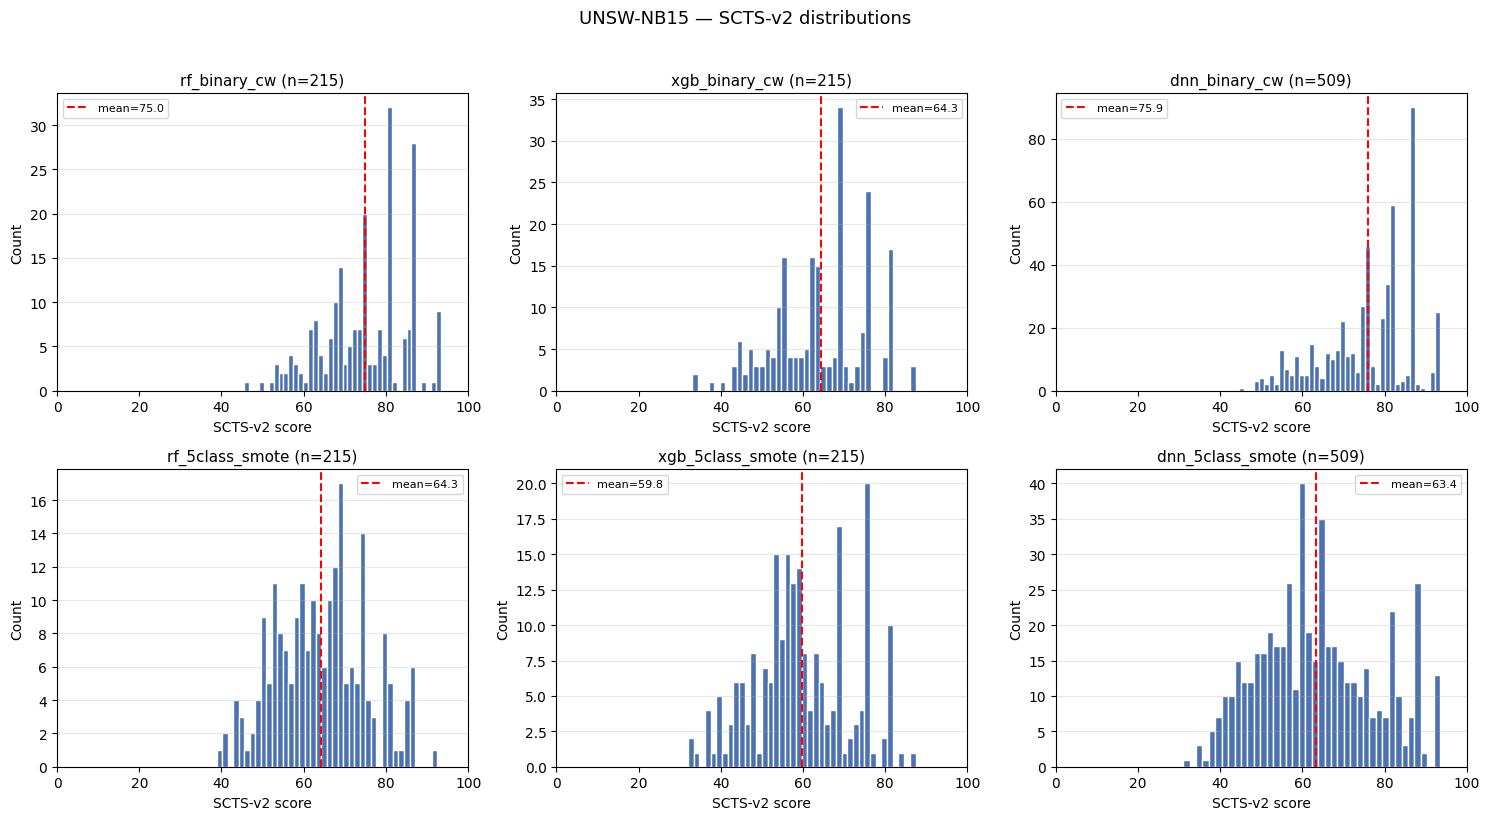

Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/unsw_scts_distributions.png


In [31]:
# Distribution of SCTS-v2 per model
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
models_ordered = list(CANONICAL.keys())
for ax, name in zip(axes.flatten(), models_ordered):
    scts = SCTS[name]
    ax.hist(scts, bins=40, color='#4C72B0', edgecolor='white')
    ax.axvline(scts.mean(), color='red', linestyle='--', label=f'mean={scts.mean():.1f}')
    ax.set_title(f'{name} (n={len(scts)})', fontsize=11)
    ax.set_xlabel('SCTS-v2 score')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('UNSW-NB15 \u2014 SCTS-v2 distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'unsw_scts_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "unsw_scts_distributions.png"}')

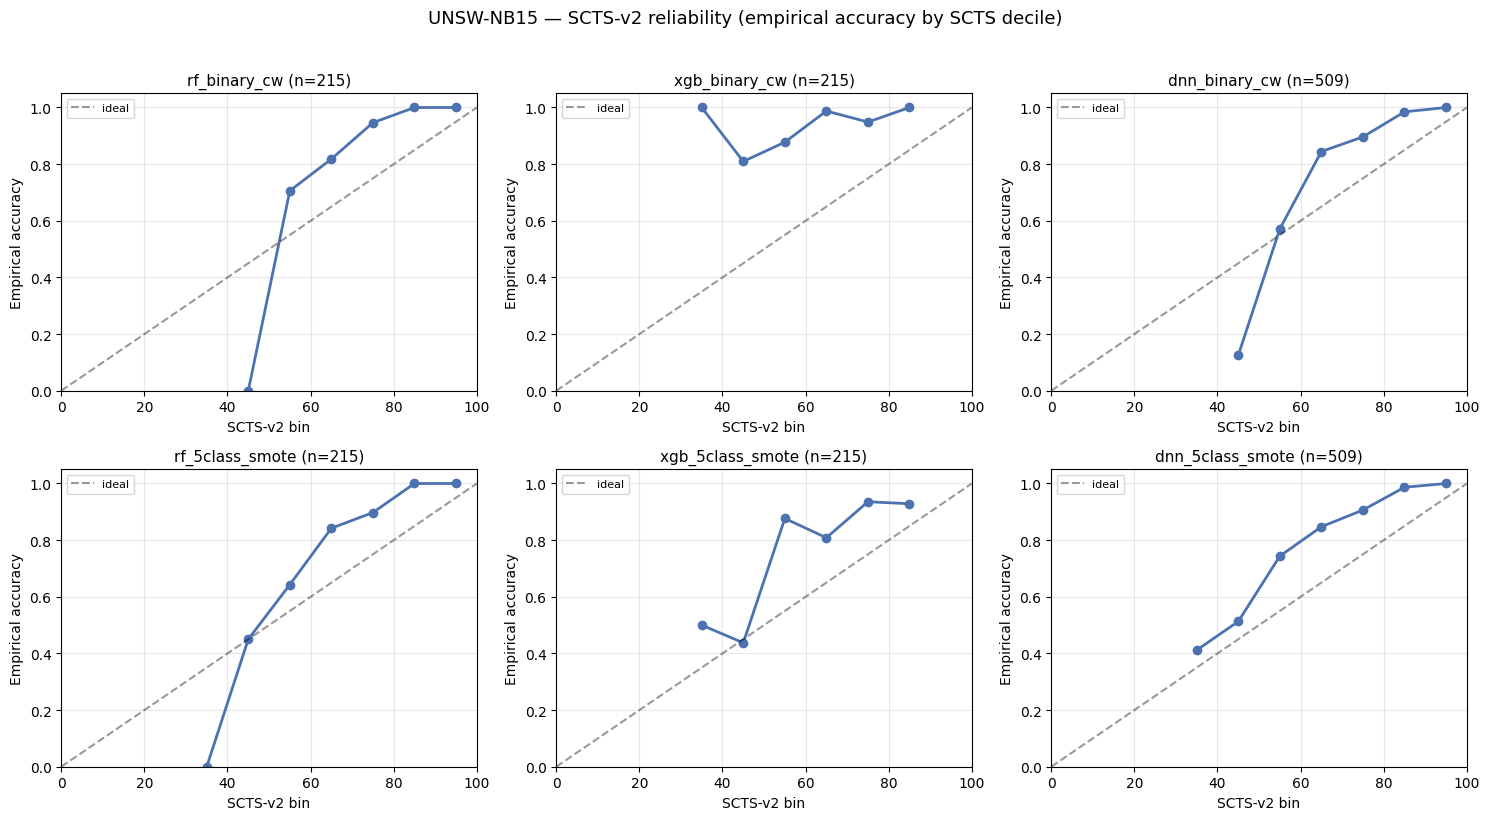

Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/unsw_scts_reliability.png


In [32]:
# Reliability: SCTS-v2 vs empirical accuracy (binned into deciles)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, name in zip(axes.flatten(), models_ordered):
    info = CANONICAL[name]
    local_idx, eval_idx, test_idx = get_stab_indices(name)
    y_true = y_test_b[test_idx] if info['target'] == 'binary' else y_test_5[test_idx]
    y_pred = get_predictions_stab(name)
    correct = (y_pred == y_true).astype(float)
    scts = SCTS[name]

    edges = np.linspace(0, 100, 11)
    centres, accs = [], []
    for i in range(10):
        mask = (scts >= edges[i]) & (scts <= edges[i+1])
        if mask.sum() > 0:
            centres.append((edges[i] + edges[i+1]) / 2)
            accs.append(correct[mask].mean())

    ax.plot(centres, accs, 'o-', color='#4C72B0', linewidth=2)
    ax.plot([0, 100], [0, 1], 'k--', alpha=0.4, label='ideal')
    ax.set_xlim(0, 100); ax.set_ylim(0, 1.05)
    ax.set_xlabel('SCTS-v2 bin')
    ax.set_ylabel('Empirical accuracy')
    ax.set_title(f'{name} (n={len(scts)})', fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle('UNSW-NB15 \u2014 SCTS-v2 reliability (empirical accuracy by SCTS decile)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'unsw_scts_reliability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DIR / "unsw_scts_reliability.png"}')

## 12. Save arrays for downstream use

In [19]:
# Per-sample SCTS arrays
scts_arrays = {name: SCTS[name] for name in CANONICAL}
np.savez(SCTS_DIR / 'unsw_scts_per_sample.npz', **scts_arrays)

# Components
comp_arrays = {}
for name in CANONICAL:
    comp_arrays[f'{name}_c1'] = C1[name]
    comp_arrays[f'{name}_c2'] = C2[name]
    comp_arrays[f'{name}_c3'] = C3[name]
np.savez(SCTS_DIR / 'unsw_components_per_sample.npz', **comp_arrays)

# Conformal metadata
conformal_data = {name: {str(a): v for a, v in CONFORMAL[name].items()} for name in CONFORMAL}
with open(SCTS_DIR / 'unsw_conformal_thresholds.json', 'w') as f:
    json.dump(conformal_data, f, indent=2)

print('Saved:')
print(f'  {SCTS_DIR / "unsw_scts_per_sample.npz"}')
print(f'  {SCTS_DIR / "unsw_components_per_sample.npz"}')
print(f'  {SCTS_DIR / "unsw_conformal_thresholds.json"}')

Saved:
  /content/drive/MyDrive/XIDS_Research/xids-research/results/scts/unsw_scts_per_sample.npz
  /content/drive/MyDrive/XIDS_Research/xids-research/results/scts/unsw_components_per_sample.npz
  /content/drive/MyDrive/XIDS_Research/xids-research/results/scts/unsw_conformal_thresholds.json


## 13. Commit and push

In [20]:
os.chdir(REPO)
!git add notebooks/08_unsw_scts.ipynb
!git add results/tables/unsw_scts_validation.csv
!git add results/tables/unsw_scts_summary.csv
!git add results/tables/unsw_scts_alpha_sensitivity.csv
!git add results/figures/unsw_scts_distributions.png
!git add results/figures/unsw_scts_reliability.png
!git add results/scts/unsw_scts_per_sample.npz
!git add results/scts/unsw_components_per_sample.npz
!git add results/scts/unsw_conformal_thresholds.json
!git status --short
!git commit -m 'Notebook 08-UNSW: SCTS-v2 trust score on UNSW-NB15 (architecture-specific subsamples, methodology mirrors NSL-KDD Notebook 07)'
!git push origin main

Refresh index: 100% (210/210), done.
 M notebooks/01_cic_data_exploration.ipynb
 M notebooks/01_unsw_data_exploration.ipynb
 M notebooks/01b_unsw_10class_sensitivity.ipynb
 M notebooks/02_cic_train_models.ipynb
 M notebooks/02_unsw_train_models.ipynb
 M notebooks/02c_unsw_dnn_retrain.ipynb
 M notebooks/03_cic_calibration.ipynb
 M notebooks/03_unsw_calibration.ipynb
 M notebooks/04_cic_shap.ipynb
 M notebooks/04_unsw_shap.ipynb
 M notebooks/05_cic_stability.ipynb
 M notebooks/05_stability_tests.ipynb
 M notebooks/05_unsw_stability.ipynb
 M notebooks/06_cic_shap_agreement.ipynb
 M notebooks/06_shap_agreement.ipynb
 M notebooks/06_unsw_shap_agreement.ipynb
 M notebooks/07_scts_v2.ipynb
 M notebooks/08_llm_alerts.ipynb
AM notebooks/08_unsw_scts.ipynb
 M notebooks/09_final_evaluation.ipynb
 M notebooks/10_baselines.ipynb
 M notebooks/11_deliverable_assembly.ipynb
A  results/figures/unsw_scts_distributions.png
A  results/figures/unsw_scts_reliability.png
A  results/scts/unsw_components_per_s

In [21]:
import json
with open(SCTS_DIR / 'unsw_conformal_thresholds.json') as f:
    cf = json.load(f)
for name, alphas in cf.items():
    print(f'\n{name}:')
    for alpha_str, info in alphas.items():
        print(f'  α={alpha_str}  threshold={info["threshold"]:.4f}  empirical_coverage={info["empirical_coverage"]:.4f}')


rf_binary_cw:
  α=0.05  threshold=0.9998  empirical_coverage=1.0000
  α=0.1  threshold=0.9998  empirical_coverage=1.0000
  α=0.2  threshold=0.9998  empirical_coverage=1.0000

xgb_binary_cw:
  α=0.05  threshold=1.0000  empirical_coverage=1.0000
  α=0.1  threshold=1.0000  empirical_coverage=1.0000
  α=0.2  threshold=1.0000  empirical_coverage=1.0000

dnn_binary_cw:
  α=0.05  threshold=1.0000  empirical_coverage=1.0000
  α=0.1  threshold=1.0000  empirical_coverage=1.0000
  α=0.2  threshold=1.0000  empirical_coverage=1.0000

rf_5class_smote:
  α=0.05  threshold=0.9999  empirical_coverage=0.9856
  α=0.1  threshold=0.9999  empirical_coverage=0.9856
  α=0.2  threshold=0.9997  empirical_coverage=0.8170

xgb_5class_smote:
  α=0.05  threshold=1.0000  empirical_coverage=1.0000
  α=0.1  threshold=1.0000  empirical_coverage=1.0000
  α=0.2  threshold=1.0000  empirical_coverage=1.0000

dnn_5class_smote:
  α=0.05  threshold=1.0000  empirical_coverage=1.0000
  α=0.1  threshold=1.0000  empirical_covera

In [22]:
# Diagnostic: check if calibrated probas are aligned to idx_eval as we assume
import numpy as np
import joblib

# Load a calibrator and the raw test-set predictions to verify alignment
name = 'rf_binary_cw'
cal_probas = load_calibrated_probas(name)
print(f'Calibrated probas shape: {cal_probas.shape}')
print(f'  (assumed: ({len(idx_eval)}, n_classes))')
print(f'  Match? {cal_probas.shape[0] == len(idx_eval)}')

# What does the raw model predict on the eval half?
rf = joblib.load(MODELS_DIR / f'{name}.joblib')
X_eval = X_test[idx_eval]
y_eval = y_test_b[idx_eval]

# Raw model predictions on the eval half, in eval-half order
raw_proba = rf.predict_proba(X_eval)
raw_pred = raw_proba.argmax(axis=1)
raw_acc = (raw_pred == y_eval).mean()
print(f'\nRaw RF prediction on eval half:')
print(f'  Shape:    {raw_proba.shape}')
print(f'  Accuracy: {raw_acc:.4f}')

# Now use the calibrated probas in the same eval-half ordering
cal_pred = cal_probas.argmax(axis=1)
cal_acc_eval_order = (cal_pred == y_eval).mean()
print(f'\nCalibrated probas as if aligned to idx_eval order:')
print(f'  Accuracy: {cal_acc_eval_order:.4f}')

# Compare: if accuracies match between raw and calibrated, alignment is to idx_eval
# Calibrated probas SHOULDN'T change argmax much (per-class isotonic is monotonic per class)

# Now check our SCTS subset accuracy
local_idx, eval_idx, test_idx = get_stab_indices(name)
print(f'\nIn the SCTS subset for {name}:')
print(f'  Indices into eval: first 5 = {eval_idx[:5]}')
print(f'  Indices into test: first 5 = {test_idx[:5]}')
print(f'  Sanity check (should match): idx_eval[eval_idx[:5]] = {idx_eval[eval_idx[:5]]}')

# Test the actual predictions from get_predictions_stab vs y_test_b[test_idx]
y_pred = cal_probas[eval_idx].argmax(axis=1)
y_true = y_test_b[test_idx]
print(f'  y_pred (first 10): {y_pred[:10]}')
print(f'  y_true (first 10): {y_true[:10]}')
print(f'  Accuracy: {(y_pred == y_true).mean():.4f}')

# Compare to alignment via raw prediction
y_pred_via_raw = raw_pred[eval_idx]
print(f'\n  If we use raw_pred[eval_idx] instead: acc = {(y_pred_via_raw == y_true).mean():.4f}')

Calibrated probas shape: (63461, 2)
  (assumed: (31731, n_classes))
  Match? False

Raw RF prediction on eval half:
  Shape:    (31731, 2)
  Accuracy: 0.8310


ValueError: operands could not be broadcast together with shapes (63461,) (31731,) 

In [23]:
# Verify: cal_probas is in test-set order
name = 'rf_binary_cw'
cal_probas = load_calibrated_probas(name)

# Use test_idx (not eval_idx) to grab the SCTS subset predictions
local_idx, eval_idx, test_idx = get_stab_indices(name)
y_pred = cal_probas[test_idx].argmax(axis=1)
y_true = y_test_b[test_idx]
acc = (y_pred == y_true).mean()
print(f'{name} with test_idx: acc = {acc:.4f}  (should be ~0.83)')

# Also verify full eval-half accuracy via test_idx-style indexing
cal_pred_eval = cal_probas[idx_eval].argmax(axis=1)
print(f'\nCalibrated full eval half: acc = {(cal_pred_eval == y_test_b[idx_eval]).mean():.4f}  (should match raw ~0.83)')

rf_binary_cw with test_idx: acc = 0.9070  (should be ~0.83)

Calibrated full eval half: acc = 0.8948  (should match raw ~0.83)


---

## How to read the results

**SCTS-v2 mean per model:** Compare with NSL-KDD numbers (63.7–83.6 range). UNSW numbers are likely lower because UNSW has lower model accuracy overall, but the relative ordering across models should be informative.

**Quartile validation gap:** The key test. On NSL-KDD, the gap between bottom-quartile and top-quartile accuracy reached +36 to +57 percentage points on 5-class. If UNSW shows a similar gap, SCTS-v2 is validated on the second dataset. If the gap is much smaller (say <20 pp), it suggests SCTS-v2 doesn't transfer as well to UNSW's noisier predictions.

**Per-class summary:** Per-class SCTS reveals which attack types the framework is most confident about. On NSL-KDD, U2R had the lowest SCTS — UNSW may show the same pattern given the small U2R sample.

**Alpha sensitivity:** SCTS-v2 should be relatively stable across α=0.05 to α=0.20 because c3 is just one of three components. If SCTS-v2 changes by >10 points across this range, the conformal component is dominating.

## What this notebook produces for the paper

After this runs, the paper can claim:
- SCTS-v2 is validated on **two independent datasets** (NSL-KDD and UNSW-NB15)
- Cross-dataset trust score generalisation is demonstrated
- The 'NSL only' scope limitation in §16.3 of the walkthrough is reduced

Sample-size honest note: SCTS-v2 on UNSW uses architecture-specific subsamples (~215 for tree models, ~509 for DNN models) due to the deep RF tree limitation. This is documented in the methodology as a known asymmetry.